In [59]:
import pandas as pd
import csv

In [ ]:
def parse_params(params_str):
    params = {}
    for item in params_str.split():
        if '=' in item:
            key, value = item.split('=', 1)
            params[key] = value
    return params

# aggregates results over all parameters except those in params_to_compare
def results_csv_to_df(csv_file, params_to_compare):
    results = []

    with open(csv_file, newline='') as f:
        reader = csv.DictReader(f, fieldnames=[
            'accuracy', 'correctly_filled_cells', 'nfe', 'not_fully_unmasked',
            'checkpoint', 'strategy', 'params'
        ])#TODO: add time, speed
        reader.__next__()  # Skip header row
        for row in reader:
            params = parse_params(row['params'])
            relevant_params = {k: v for k, v in params.items() if k in params_to_compare}
            row_dict = {
                'accuracy': float(row['accuracy']),
                'correctly_filled_cells': float(row['correctly_filled_cells']),
                'checkpoint': row['checkpoint'],
                'strategy': row['strategy']
            }
            row_dict.update(relevant_params)
            results.append(row_dict)
    
    results_df = pd.DataFrame(results)
    aggregated_df = results_df.groupby(params_to_compare + ['checkpoint', 'strategy']).agg(
        accuracy_mean=pd.NamedAgg(column='accuracy', aggfunc='mean'),
        accuracy_std=pd.NamedAgg(column='accuracy', aggfunc='std'),
        correctly_filled_cells_mean=pd.NamedAgg(column='correctly_filled_cells', aggfunc='mean'),
        correctly_filled_cells_std=pd.NamedAgg(column='correctly_filled_cells', aggfunc='std')
    ).reset_index()

    return aggregated_df

In [61]:
params_to_compare=['pruning_num_beams', 'branching_factor', 'score_time', 'score_method']
df = results_csv_to_df('results_compare_beam_search_parameters.csv', params_to_compare)
df

,pruning_num_beams,branching_factor,score_time,score_method,checkpoint,strategy,accuracy_mean,accuracy_std,correctly_filled_cells_mean,correctly_filled_cells_std
0,1,2,inferred,avg,checkpoints/gidd_0_2/300_epochs,gidd_change_based_on_model_confidence_to_change,0.7156,NaN,0.8745,NaN
1,1,2,inferred,avg,checkpoints/gidd_0_2/300_epochs,gidd_change_low_confidence_positions,0.7203,NaN,0.8740,NaN
2,1,2,inferred,avg,checkpoints/gidd_0_2/300_epochs,gidd_keep_where_confident,0.7156,NaN,0.8745,NaN
3,1,2,inferred,avg,checkpoints/gidd_0_2/300_epochs,gidd_prob_to_recover_data,0.7203,NaN,0.8750,NaN
4,1,2,inferred,avg,checkpoints/mdlm/300_epochs,mdlm_adaptive_score_select_update,0.6781,NaN,0.8663,NaN
...,...,...,...,...,...,...,...,...,...,...
115,4,4,t_zero,min,checkpoints/gidd_0_2/300_epochs,gidd_change_based_on_model_confidence_to_change,0.7953,NaN,0.9065,NaN
116,4,4,t_zero,min,checkpoints/gidd_0_2/300_epochs,gidd_change_low_confidence_positions,0.7891,NaN,0.9000,NaN
117,4,4,t_zero,min,checkpoints/gidd_0_2/300_epochs,gidd_keep_where_confident,0.7953,NaN,0.9060,NaN
118,4,4,t_zero,min,checkpoints/gidd_0_2/300_epochs,gidd_prob_to_recover_data,0.7812,NaN,0.9018,NaN


In [65]:
# compare score_method
score_methods = df.groupby(['checkpoint', 'strategy'] + [param for param in params_to_compare if param != 'score_method'] + ['score_method'])['accuracy_mean'].mean().unstack()
# score_methods = df.groupby(['checkpoint', 'strategy'] + ['score_method'])['accuracy_mean'].mean().unstack()
score_methods

score_method                                                                                                                      avg  \
checkpoint                      strategy                                        pruning_num_beams branching_factor score_time           
checkpoints/gidd_0_2/300_epochs gidd_change_based_on_model_confidence_to_change 1                 2                inferred    0.7156   
                                                                                                                   t_zero      0.7078   
                                                                                2                 2                inferred    0.7312   
                                                                                                                   t_zero      0.7297   
                                                                                                  4                inferred    0.7766   
                                                                                                                   t_zero      0.7531   
                                                                                4                 4                inferred    0.8016   
                                                                                                                   t_zero      0.7969   
                                gidd_change_low_confidence_positions            1                 2                inferred    0.7203   
                                                                                                                   t_zero      0.7063   
                                                                                2                 2                inferred    0.7375   
                                                                                                                   t_zero      0.7359   
                                                                                                  4                inferred    0.7828   
                                                                                                                   t_zero      0.7688   
                                                                                4                 4                inferred    0.8094   
                                                                                                                   t_zero      0.8047   
                                gidd_keep_where_confident                       1                 2                inferred    0.7156   
                                                                                                                   t_zero      0.7078   
                                                                                2                 2                inferred    0.7312   
                                                                                                                   t_zero      0.7297   
                                                                                                  4                inferred    0.7766   
                                                                                                                   t_zero      0.7531   
                                                                                4                 4                inferred    0.8016   
                                                                                                                   t_zero      0.7969   
                                gidd_prob_to_recover_data                       1                 2                inferred    0.7203   
                                                                                                                   t_zero      0.7156   
                                                                                2                 2                inferred    0.7328   
                           

In [66]:
# compare score_time
score_methods = df.groupby(['checkpoint', 'strategy'] + [param for param in params_to_compare if param != 'score_time'] + ['score_time'])['accuracy_mean'].mean().unstack()
# score_methods = df.groupby(['checkpoint', 'strategy'] + ['score_time'])['accuracy_mean'].mean().unstack()
score_methods

score_time                                                                                                                                              inferred  \
checkpoint                      strategy                                        pruning_num_beams branching_factor score_method                                    
checkpoints/gidd_0_2/300_epochs gidd_change_based_on_model_confidence_to_change 1                 2                avg                                    0.7156   
                                                                                                                   avg_all_using_confidence_for_masked    0.7156   
                                                                                                                   min                                    0.7188   
                                                                                2                 2                avg                                    0.7312   
                                                                                                                   avg_all_using_confidence_for_masked    0.7297   
                                                                                                                   min                                    0.7312   
                                                                                                  4                avg                                    0.7766   
                                                                                                                   avg_all_using_confidence_for_masked    0.7641   
                                                                                                                   min                                    0.7750   
                                                                                4                 4                avg                                    0.8016   
                                                                                                                   avg_all_using_confidence_for_masked    0.7859   
                                                                                                                   min                                    0.7969   
                                gidd_change_low_confidence_positions            1                 2                avg                                    0.7203   
                                                                                                                   avg_all_using_confidence_for_masked    0.7156   
                                                                                                                   min                                    0.7188   
                                                                                2                 2                avg                                    0.7375   
                                                                                                                   avg_all_using_confidence_for_masked    0.7328   
                                                                                                                   min                                    0.7328   
                                                                                                  4                avg                                    0.7828   
                                                                                                                   avg_all_using_confidence_for_masked    0.7719   
                                                                                                                   min                                    0.7844   
                                                                                4                 4                avg                                    0.8094   
                                                                

In [67]:
# Get best score_method and score_time per pruning_num_beams and branching_factor
best_method_and_time = df.loc[df.groupby(['checkpoint', 'strategy', 'pruning_num_beams', 'branching_factor'])['accuracy_mean'].idxmax()]#.reset_index(drop=True)
best_method_and_time[['checkpoint', 'strategy', 'pruning_num_beams', 'branching_factor', 'score_method', 'score_time', 'accuracy_mean']]

,checkpoint,strategy,pruning_num_beams,branching_factor,score_method,score_time,accuracy_mean
10,checkpoints/gidd_0_2/300_epochs,gidd_change_based_on_model_confidence_to_change,1,2,min,inferred,0.7188
30,checkpoints/gidd_0_2/300_epochs,gidd_change_based_on_model_confidence_to_change,2,2,avg,inferred,0.7312
60,checkpoints/gidd_0_2/300_epochs,gidd_change_based_on_model_confidence_to_change,2,4,avg,inferred,0.7766
90,checkpoints/gidd_0_2/300_epochs,gidd_change_based_on_model_confidence_to_change,4,4,avg,inferred,0.8016
1,checkpoints/gidd_0_2/300_epochs,gidd_change_low_confidence_positions,1,2,avg,inferred,0.7203
31,checkpoints/gidd_0_2/300_epochs,gidd_change_low_confidence_positions,2,2,avg,inferred,0.7375
71,checkpoints/gidd_0_2/300_epochs,gidd_change_low_confidence_positions,2,4,min,inferred,0.7844
91,checkpoints/gidd_0_2/300_epochs,gidd_change_low_confidence_positions,4,4,avg,inferred,0.8094
12,checkpoints/gidd_0_2/300_epochs,gidd_keep_where_confident,1,2,min,inferred,0.7188
32,checkpoints/gidd_0_2/300_epochs,gidd_keep_where_confident,2,2,avg,inferred,0.7312


/tmp/ipykernel_2242510/4026978002.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


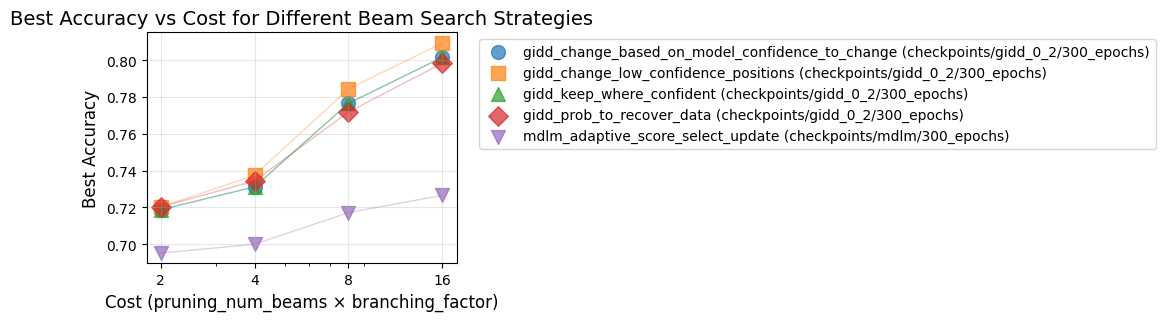

In [91]:
# Plot the best accuracy for each strategy over the cost (=pruning_num_beams * branching_factor)
import matplotlib.pyplot as plt

# Calculate cost and prepare data for plotting
best_method_and_time['cost'] = best_method_and_time['pruning_num_beams'].astype(int) * best_method_and_time['branching_factor'].astype(int)

# Create the plot
plt.figure(figsize=(4, 3))

# Get unique strategies and checkpoints for plotting
strategies = best_method_and_time['strategy'].unique()
checkpoints = best_method_and_time['checkpoint'].unique()

# Use different markers and colors for each strategy-checkpoint combination
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
colors = plt.cm.tab10(range(len(strategies) * len(checkpoints)))

plot_idx = 0
for strategy in strategies:
    for checkpoint in checkpoints:
        subset = best_method_and_time[
            (best_method_and_time['strategy'] == strategy) & 
            (best_method_and_time['checkpoint'] == checkpoint)
        ]
        
        if not subset.empty:
            plt.scatter(subset['cost'], subset['accuracy_mean'], 
                       label=f'{strategy} ({checkpoint})',
                       marker=markers[plot_idx % len(markers)],
                       color=colors[plot_idx],
                       s=100, alpha=0.7)
            
            # Connect points with lines for the same strategy-checkpoint combination
            subset_sorted = subset.sort_values('cost')
            plt.plot(subset_sorted['cost'], subset_sorted['accuracy_mean'],
                    color=colors[plot_idx], alpha=0.3, linewidth=1)
            
            plot_idx += 1

plt.xlabel('Cost (pruning_num_beams × branching_factor)', fontsize=12)
plt.ylabel('Best Accuracy', fontsize=12)
plt.title('Best Accuracy vs Cost for Different Beam Search Strategies', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Make cost axis logarithmic and set specific ticks only
plt.xscale('log')
plt.xticks([2, 4, 8, 16], ['2', '4', '8', '16'])
# Disable minor ticks to prevent automatic labels
plt.gca().xaxis.set_minor_formatter(plt.NullFormatter())
# plt.ylim(0, 1)

plt.tight_layout()
plt.show()